# Frank–Wolfe Algorithm: Projection-Free Constrained Optimization

Minimizing a smooth function $f$ over a **convex constraint set** $\mathcal{K}$:
$$
\min_{x \in \mathcal{K}} f(x),
$$
is one of the core problems in optimization. When $\mathcal{K}$ is simple (a ball, simplex, polytope), the **Frank–Wolfe algorithm** (also called the **conditional gradient method**) offers an elegant projection-free approach.

## The algorithm

At each iteration, Frank–Wolfe linearizes $f$ around the current point and minimizes the linear approximation over $\mathcal{K}$:
$$
s_t = \arg\min_{s \in \mathcal{K}} \langle \nabla f(x_t),\, s \rangle, \qquad x_{t+1} = (1 - \gamma_t) x_t + \gamma_t s_t,
$$
where $\gamma_t \in [0,1]$ is a step size (typically $\gamma_t = 2/(t+2)$). The update is a **convex combination**, so $x_{t+1} \in \mathcal{K}$ automatically — no projection needed.

## Key properties

- **Projection-free**: only requires a **linear minimization oracle** (LMO) over $\mathcal{K}$, which is often much cheaper than computing projections onto $\mathcal{K}$.
- **Convergence**: for $L$-smooth convex $f$, $f(x_t) - f(x^*) \leq \frac{2LC^2}{t+2}$ where $C = \operatorname{diam}(\mathcal{K})$.
- **Sparse iterates**: each $x_t$ is a convex combination of at most $t+1$ vertices of $\mathcal{K}$, giving **sparse solutions** useful for matrix factorization, structured sparsity, and semidefinite programming.
- **Frank–Wolfe gap**: $g_t = \langle \nabla f(x_t), x_t - s_t \rangle \geq 0$ is a certificate of suboptimality: $f(x_t) - f(x^*) \leq g_t$.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown

plt.rcParams['figure.dpi'] = 120

## Frank–Wolfe in 2D: geometric illustration

We minimize a quadratic $f(z) = \tfrac{1}{2}|z - z_0|^2$ over a convex polytope $\mathcal{K}$ (triangle, square). The solution is the projection of $z_0$ onto $\mathcal{K}$. We trace the full Frank–Wolfe trajectory from the initial vertex to the solution.

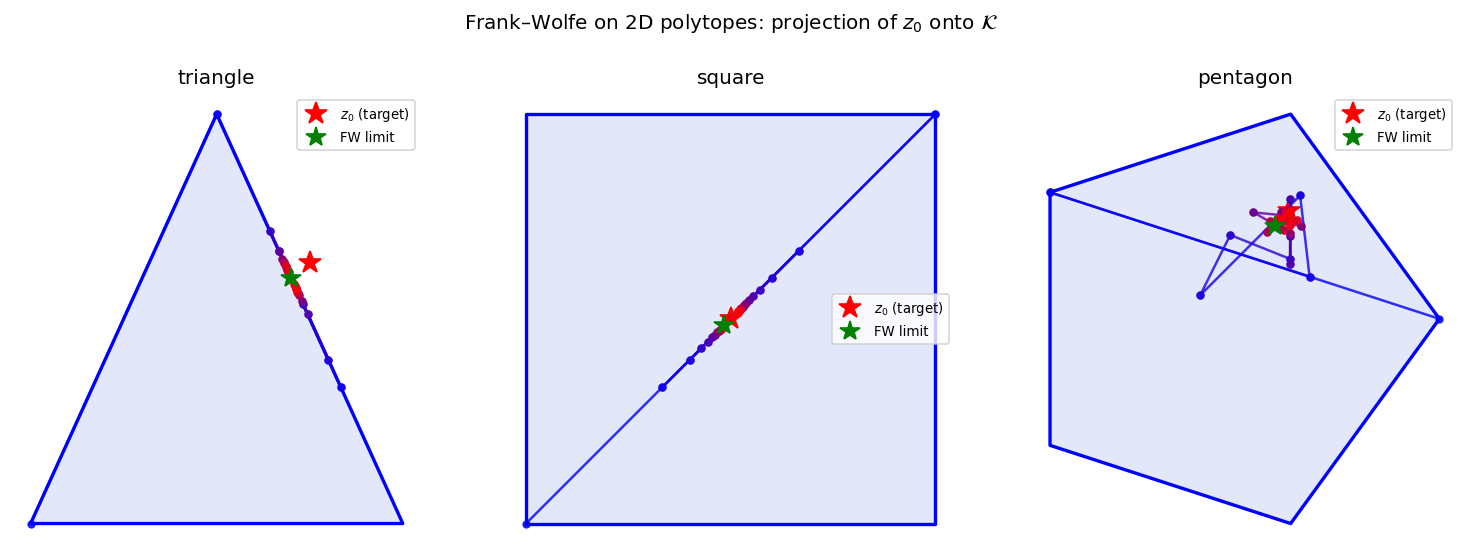

In [2]:
def frank_wolfe_2d(vertices, z0, n_iter=40):
    """Frank-Wolfe to minimize 0.5*|z-z0|^2 over conv(vertices)."""
    vertices = np.array(vertices)  # (m, 2)
    z = vertices[0].astype(float).copy()
    trajectory = [z.copy()]
    gaps = []
    for t in range(n_iter):
        grad = z - z0
        # LMO: minimize <grad, s> over vertices
        idx = np.argmin(vertices @ grad)
        s = vertices[idx]
        gap = np.dot(grad, z - s)
        gaps.append(gap)
        gamma = 2.0 / (t + 2)
        z = (1 - gamma) * z + gamma * s
        trajectory.append(z.copy())
    return np.array(trajectory), np.array(gaps)


polytopes = {
    'triangle': np.array([[-1, -1], [1, -1], [0, 1.2]], dtype=float),
    'square':   np.array([[-1, -1], [1, -1], [1, 1], [-1, 1]], dtype=float),
    'pentagon': np.array([[np.cos(2*np.pi*k/5), np.sin(2*np.pi*k/5)] for k in range(5)]),
}

z0_targets = {
    'triangle': np.array([0.5, 0.4]),
    'square':   np.array([0.0, 0.0]),
    'pentagon': np.array([0.3, 0.5]),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (name, verts) in zip(axes, polytopes.items()):
    z0 = z0_targets[name]
    traj, gaps = frank_wolfe_2d(verts, z0, 30)

    ax.fill(*verts.T, alpha=0.15, color='royalblue')
    ax.plot(*np.vstack([verts, verts[0]]).T, 'b-', lw=2)
    ax.plot(*z0, 'r*', ms=14, label='$z_0$ (target)')

    # Colored trajectory
    for i in range(len(traj)-1):
        t_norm = i / (len(traj)-2)
        ax.plot(*traj[i:i+2].T, '-o', ms=4, lw=1.5,
                color=(t_norm, 0, 1-t_norm), alpha=0.8)
    ax.plot(*traj[-1], 'g*', ms=12, label='FW limit')
    ax.set_title(name); ax.set_aspect('equal'); ax.legend(fontsize=8)
    ax.axis('off')

fig.suptitle('Frank–Wolfe on 2D polytopes: projection of $z_0$ onto $\\mathcal{K}$', y=1.02)
plt.tight_layout()
plt.show()

## Convergence analysis

For $L$-smooth convex $f$, the Frank–Wolfe gap $g_t = \langle \nabla f(x_t), x_t - s_t \rangle$ provides a convergence certificate and decreases as $O(1/t)$. We verify this rate and compare it to projected gradient descent.

/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_6900/1985805141.py:61: RuntimeWarning: divide by zero encountered in divide
  axes[0].loglog(iters[1:]+1, 1.5*err_fw[5]/(iters[1:]+1-5+1), 'k--', lw=1, label='$O(1/t)$')


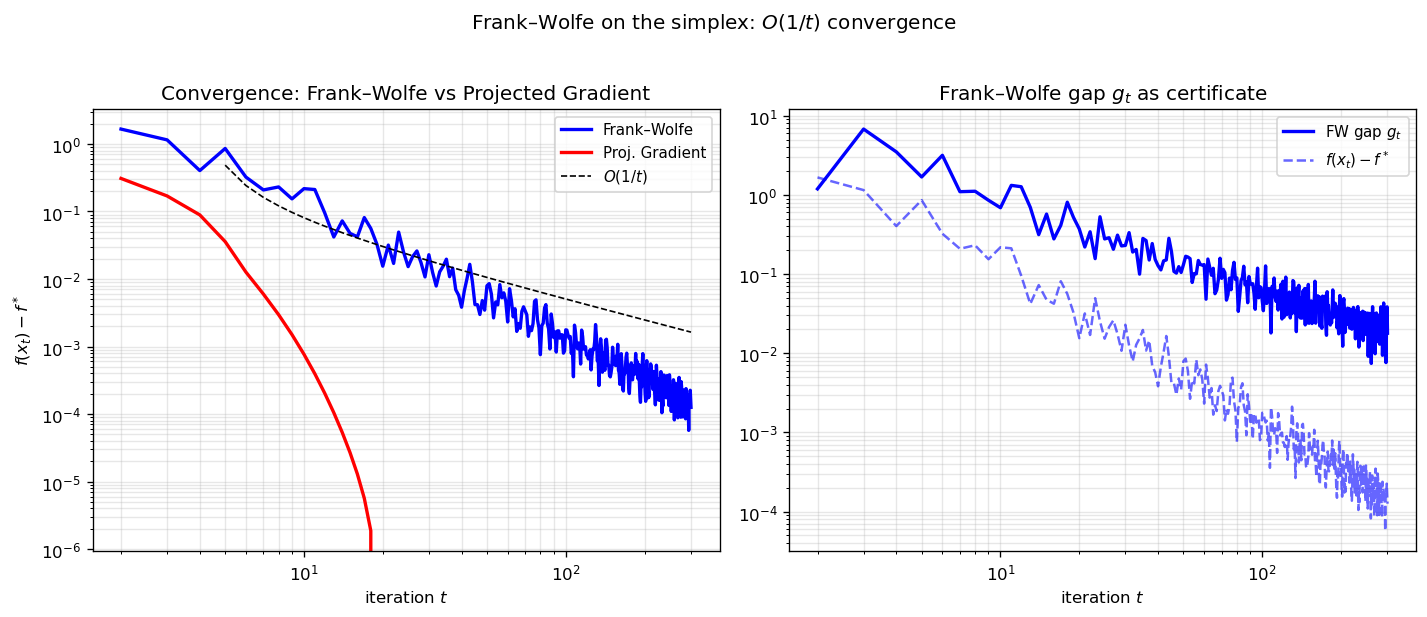

In [3]:
from scipy.optimize import linprog

def proj_simplex(v):
    """Project v onto the probability simplex."""
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - 1
    ind = np.arange(1, n+1)
    cond = u - cssv / ind > 0
    rho = ind[cond][-1]
    theta = cssv[cond][-1] / rho
    return np.maximum(v - theta, 0)

# Minimize quadratic over the simplex
rng = np.random.default_rng(7)
d = 10
A = rng.standard_normal((d, d))
A = A @ A.T + 0.5 * np.eye(d)  # PSD
b = rng.standard_normal(d)

f = lambda x: 0.5 * x @ A @ x - b @ x
df = lambda x: A @ x - b

# Frank-Wolfe on simplex
def fw_simplex(n_iter=200):
    x = np.ones(d) / d
    traj = [x.copy()]; gaps_fw = []
    for t in range(n_iter):
        g = df(x)
        s = np.zeros(d); s[np.argmin(g)] = 1.0  # LMO on simplex
        gap = g @ (x - s)
        gaps_fw.append(gap)
        gamma = 2.0 / (t + 2)
        x = (1-gamma)*x + gamma*s
        traj.append(x.copy())
    return np.array(traj), np.array(gaps_fw)

# Projected gradient on simplex
def pgd_simplex(n_iter=200, lr=0.05):
    x = np.ones(d) / d
    traj = [x.copy()]
    for t in range(n_iter):
        x = proj_simplex(x - lr * df(x))
        traj.append(x.copy())
    return np.array(traj)

traj_fw, gaps_fw = fw_simplex(300)
traj_pgd = pgd_simplex(300)

# Optimal value via long FW run
x_star = fw_simplex(2000)[0][-1]
f_star = f(x_star)

err_fw  = np.array([f(x) - f_star for x in traj_fw])
err_pgd = np.array([f(x) - f_star for x in traj_pgd])
iters = np.arange(len(err_fw))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].loglog(iters[1:]+1, err_fw[1:], 'b-', lw=2, label='Frank–Wolfe')
axes[0].loglog(iters[1:]+1, err_pgd[1:], 'r-', lw=2, label='Proj. Gradient')
axes[0].loglog(iters[1:]+1, 1.5*err_fw[5]/(iters[1:]+1-5+1), 'k--', lw=1, label='$O(1/t)$')
axes[0].set_xlabel('iteration $t$'); axes[0].set_ylabel('$f(x_t) - f^*$')
axes[0].set_title('Convergence: Frank–Wolfe vs Projected Gradient')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3, which='both')

axes[1].loglog(iters[1:]+1, gaps_fw, 'b-', lw=2, label='FW gap $g_t$')
axes[1].loglog(iters[1:]+1, err_fw[1:], 'b--', lw=1.5, alpha=0.6, label='$f(x_t)-f^*$')
axes[1].set_xlabel('iteration $t$')
axes[1].set_title('Frank–Wolfe gap $g_t$ as certificate')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, which='both')
fig.suptitle('Frank–Wolfe on the simplex: $O(1/t)$ convergence', y=1.02)
plt.tight_layout()
plt.show()

## Sparse iterates: support growth

A key property of Frank–Wolfe is that $x_t$ is a convex combination of at most $t+1$ vertices. This sparsity is valuable in machine learning (e.g. kernel methods: each FW step adds one support vector) and matrix factorization.

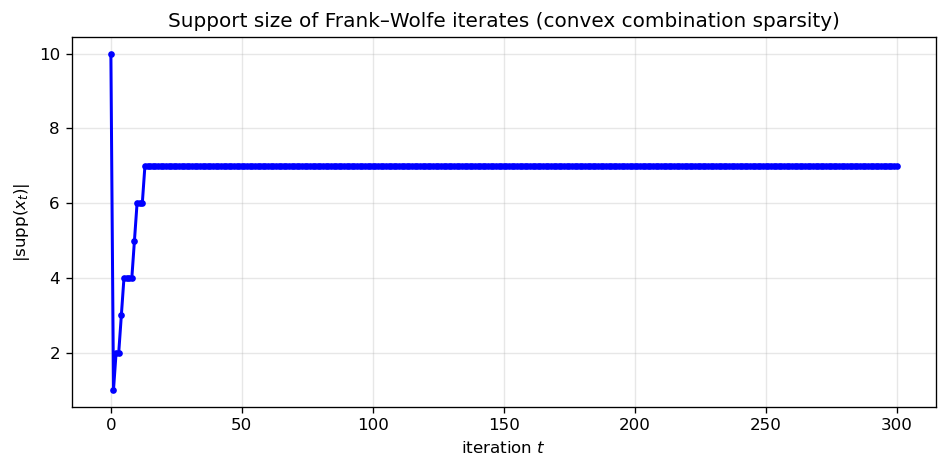

In [4]:
# Track support (non-zero entries) of FW iterates on simplex
threshold = 1e-6
support_sizes = [np.sum(x > threshold) for x in traj_fw]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(support_sizes, 'b-o', ms=3, lw=1.8)
ax.set_xlabel('iteration $t$'); ax.set_ylabel('$|\\text{supp}(x_t)|$')
ax.set_title('Support size of Frank–Wolfe iterates (convex combination sparsity)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interactive: explore polytope shapes

Choose between a triangle, square, and pentagon constraint set and vary the number of iterations. Watch the zigzag trajectory converge to the constrained minimum.

In [5]:
def show_fw(polytope='triangle', n_iter=20):
    verts = polytopes[polytope]
    z0 = z0_targets[polytope]
    traj, gaps = frank_wolfe_2d(verts, z0, n_iter)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].fill(*verts.T, alpha=0.15, color='royalblue')
    axes[0].plot(*np.vstack([verts, verts[0]]).T, 'b-', lw=2)
    axes[0].plot(*z0, 'r*', ms=14)
    for i in range(len(traj)-1):
        t_norm = i / max(1, len(traj)-2)
        axes[0].plot(*traj[i:i+2].T, '-o', ms=5, lw=2,
                     color=(t_norm, 0, 1-t_norm))
    axes[0].plot(*traj[-1], 'g*', ms=14)
    axes[0].set_title(f'{polytope}: {n_iter} iterations')
    axes[0].set_aspect('equal'); axes[0].axis('off')

    axes[1].semilogy(gaps + 1e-14, 'b-o', ms=3, lw=2)
    axes[1].set_xlabel('iteration'); axes[1].set_ylabel('FW gap $g_t$')
    axes[1].set_title('Frank–Wolfe gap'); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_fw,
         polytope=Dropdown(options=list(polytopes.keys()), description='set $\\mathcal{K}$'),
         n_iter=IntSlider(value=15, min=2, max=50, step=1, description='iters'));

interactive(children=(Dropdown(description='set $\\mathcal{K}$', options=('triangle', 'square', 'pentagon'), v…

## Bibliographical resources

- Frank, M. and Wolfe, P. (1956). An algorithm for quadratic programming. *Naval Research Logistics Quarterly*, 3(1–2), 95–110.
- Jaggi, M. (2013). Revisiting Frank-Wolfe: Projection-free sparse convex optimization. *ICML Proceedings*, 427–435.
- Lacoste-Julien, S. and Jaggi, M. (2015). On the global linear convergence of Frank-Wolfe optimization variants. *NeurIPS Proceedings*.
- Hazan, E. (2016). Introduction to online convex optimization. *Foundations and Trends in Optimization*, 2(3–4), 157–325.
- Combettes, P. L. and Müller, C. L. (2021). Perspective functions: proximal calculus and applications in high-dimensional statistics. *Journal of Mathematical Analysis and Applications*, 501(2).